In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


import seaborn as sns
import matplotlib.patches as mpatches
import time

import collections
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# загрузка данных и структура данных
df=pd.read_csv('/content/drive/MyDrive/creditcard.csv')

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Небольшой описательный анализ.

In [9]:
print("Размер данных:", df.shape)

Размер данных: (284807, 31)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [10]:
df.describe() #Описательная статистика

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Проверим на наличие пропусков в данных.

In [5]:
df.isnull().sum() #Пропущенные значения

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


Выведем названия столбцов.

In [8]:
print("Названия столбцов:")
print(df.columns.tolist())

Названия столбцов:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


Еще раз оценим отношение классов целевой переменной.

In [11]:
# вывод на печать 'Обычные транзакции составляют' и 'Мошеннические транзакции составляют' в процентном соотношении
class_counts = df['Class'].value_counts()
total = len(df)
n_trans = (class_counts[0] / total) * 100
f_trans = (class_counts[1] / total) * 100

print(f'Обычные транзакции составляют {n_trans:.2f}% данных')
print(f'Мошеннические транзакции составляют {f_trans:.2f}% данных')

Обычные транзакции составляют 99.83% данных
Мошеннические транзакции составляют 0.17% данных


In [12]:
# df['Class'].value_counts() - возвращает словарик,
# где ключ - уникальные значения в столбце Class кол-во значений
# value - сколько всего записей имело эти значения

# так как это словарь, то чтобы получить значения, обращаемся по ключу:
class_counts = df['Class'].value_counts()
non_fraud_count = class_counts[0]
fraud_count = class_counts[1]

In [13]:
# вывод отношения классов целевой переменной, но записанный через f строку
n_trans = (non_fraud_count / len(df)) * 100
f_trans = (fraud_count / len(df)) * 100

print(f'Обычные транзакции составляют {n_trans:.2f}% данных')
print(f'Мошеннические транзакции составляют {f_trans:.2f}% данных')

Обычные транзакции составляют 99.83% данных
Мошеннические транзакции составляют 0.17% данных


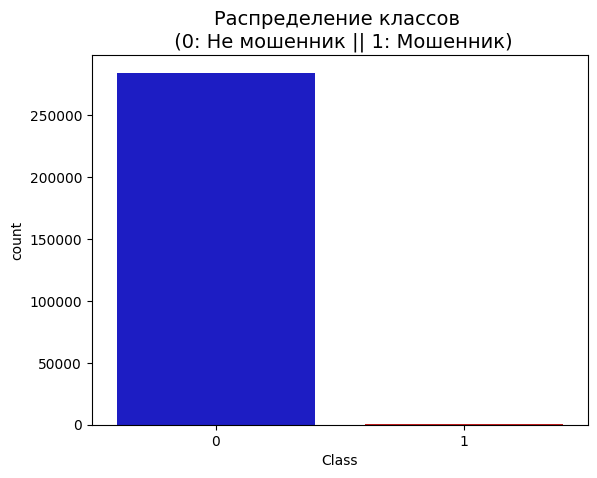

In [16]:
colors = ["#0101DF", "#DF0101"]

# строим гистограмму целевой переменной:
sns.countplot(x='Class', data=df, palette=colors)
plt.title('Распределение классов \n (0: Не мошенник || 1: Мошенник)', fontsize=14)
plt.show()

Построим распределения по суммам и времени транзакций.

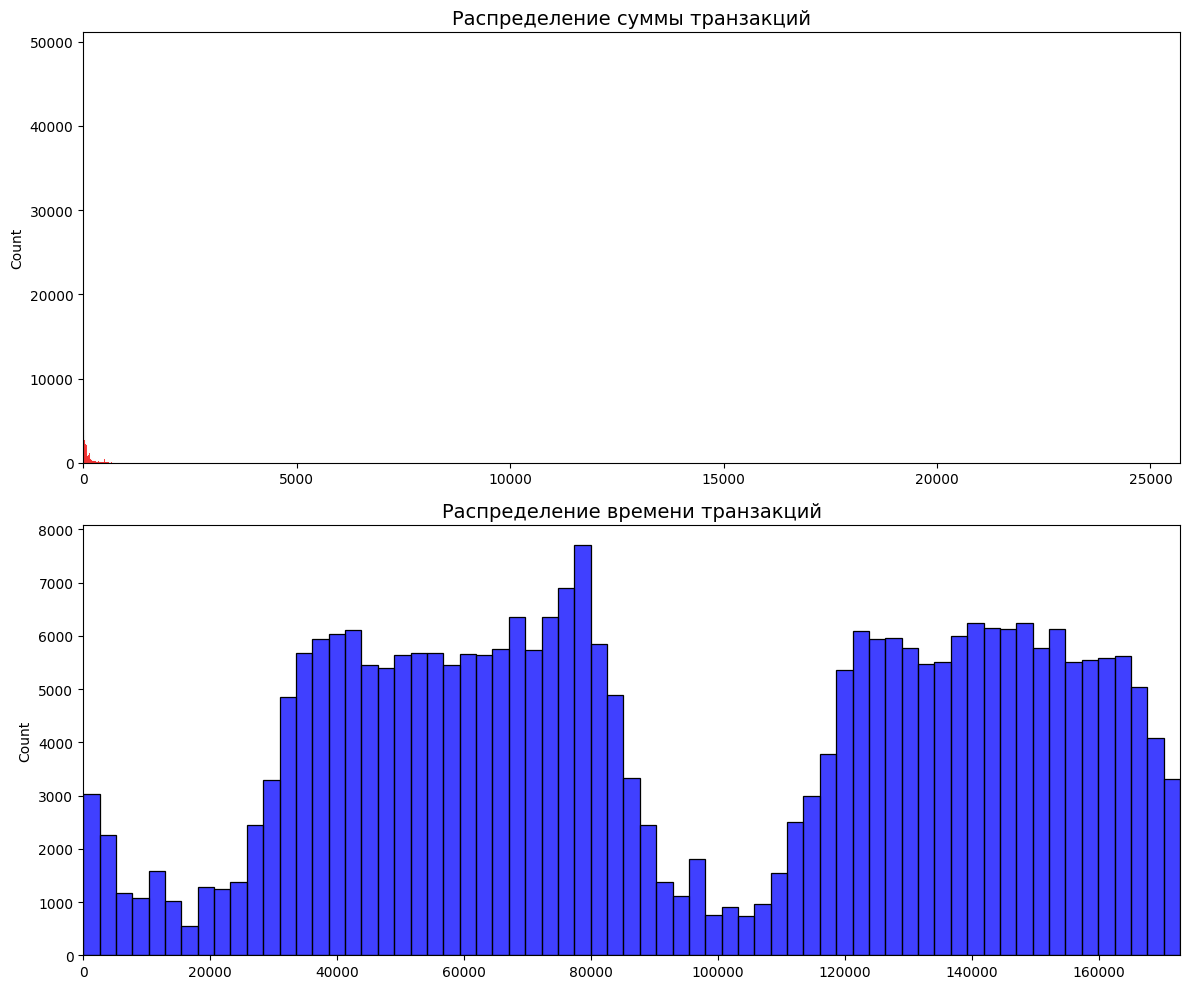

In [43]:
# Графики распределения суммы и времени транзакций
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

amount_val = df['Amount'].values
time_val = df['Time'].values

# График распределения суммы транзакций
sns.histplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Распределение суммы транзакций', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])

# График распределения времени транзакций
sns.histplot(time_val, ax=ax[1], color='b')
ax[1].set_title('Распределение времени транзакций', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])

plt.tight_layout()
plt.show()

Масштабирование

In [22]:
from sklearn.model_selection import train_test_split
# Поскольку большая часть наших данных уже масштабирована, мы должны масштабировать столбцы,
# которые остались (Amount и Time)
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler() # Менее чувствителен к выбросам, чем просто стандартизация

X = df.drop('Class', axis=1)
y = df['Class']

original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size=0.2,
                                                                                    random_state = 42)


# Посмотрим, какие типы данных возвращаются после разделения:
rt_tmp = original_Xtrain['Amount']
print (f'Тип данных original_Xtrain["Amount"] {type(rt_tmp)}')
print (f'Тип данных original_Xtrain["Amount"].values {type(rt_tmp.values)}')
print (f'Данные original_Xtrain["Amount"].values {rt_tmp.values}')
print (f'Тип данных original_Xtrain["Amount"].values.reshape(-1,1) {type(rt_tmp.values.reshape(-1,1))}')
print (f'Данные original_Xtrain["Amount"].values.reshape(-1,1) \n{rt_tmp.values.reshape(-1,1)} \n')

# вот последнее представление - как раз то, что нужно для RobustScaler . Преобразовываем так все нужные столбцы.

original_Xtrain['scaled_amount'] = rob_scaler.fit_transform(original_Xtrain['Amount'].values.reshape(-1,1))
original_Xtest['scaled_amount'] = rob_scaler.transform(original_Xtest['Amount'].values.reshape(-1,1))

original_Xtrain['scaled_time'] = rob_scaler.fit_transform(original_Xtrain['Time'].values.reshape(-1,1))
original_Xtest['scaled_time'] = rob_scaler.transform(original_Xtest['Time'].values.reshape(-1,1))


original_Xtrain.drop(['Time','Amount'], axis=1, inplace=True)
original_Xtest.drop(['Time','Amount'], axis=1, inplace=True)

original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

print('Распределение классов: \n')
print("Обучающий набор:", train_counts_label/ len(original_ytrain))
print("Тестовый набор:", test_counts_label/ len(original_ytest))

Тип данных original_Xtrain["Amount"] <class 'pandas.core.series.Series'>
Тип данных original_Xtrain["Amount"].values <class 'numpy.ndarray'>
Данные original_Xtrain["Amount"].values [  9.99  45.9   11.99 ...   3.94   1.   113.  ]
Тип данных original_Xtrain["Amount"].values.reshape(-1,1) <class 'numpy.ndarray'>
Данные original_Xtrain["Amount"].values.reshape(-1,1) 
[[  9.99]
 [ 45.9 ]
 [ 11.99]
 ...
 [  3.94]
 [  1.  ]
 [113.  ]] 

Распределение классов: 

Обучающий набор: [0.99827075 0.00172925]
Тестовый набор: [0.99827955 0.00172045]


## Метод Random Under-Sampling

In [23]:
# Поскольку наши классы сильно не сбалансированы, мы должны сделать их эквивалентными,
# чтобы получить нормальное распределение классов.

# Перемешаем данные перед созданием подвыборок

df = df.sample(frac=1)

fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492] # берем последние 492 транзакции

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Перемешивание строк датасета
new_df = normal_distributed_df.sample(frac=1, random_state=42)

new_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
94787,65032.0,1.584033,-1.194485,-1.146295,-2.505110,0.985758,3.233675,-1.493523,0.747952,-1.984370,...,-0.269927,-0.522083,0.002811,0.981535,0.550247,-0.190786,0.033466,0.013529,9.00,0
15751,27187.0,-24.590245,14.044567,-26.278701,6.320089,-18.224513,-4.609968,-17.681003,16.213627,-3.794093,...,1.777063,-1.804874,-1.140605,0.152234,1.715997,-0.220471,1.434951,0.422492,99.99,1
75853,56279.0,-2.523968,2.542494,-0.633561,1.749746,-2.002466,0.446253,-0.337583,1.306368,-0.474935,...,0.262201,0.339894,0.109491,0.110738,-0.458507,-0.268091,-1.364814,-0.113810,155.24,0
26802,34256.0,0.539276,1.554890,-2.066180,3.241617,0.184736,0.028330,-1.515521,0.537035,-1.999846,...,0.371773,0.111955,-0.305225,-1.053835,0.771175,0.240878,0.418435,0.232170,19.02,1
263877,161154.0,-3.387601,3.977881,-6.978585,1.657766,-1.100500,-3.599487,-3.686651,1.942252,-3.065089,...,1.043587,0.262189,-0.479224,-0.326638,-0.156939,0.113807,0.354124,0.287592,0.38,1


In [25]:
df.to_csv("/content/drive/MyDrive/Colab Notebooks/creditcard_full.csv")

In [26]:
new_df.shape

(984, 31)

Распределение классов в подвыборке
Class
0    492
1    492
Name: count, dtype: int64


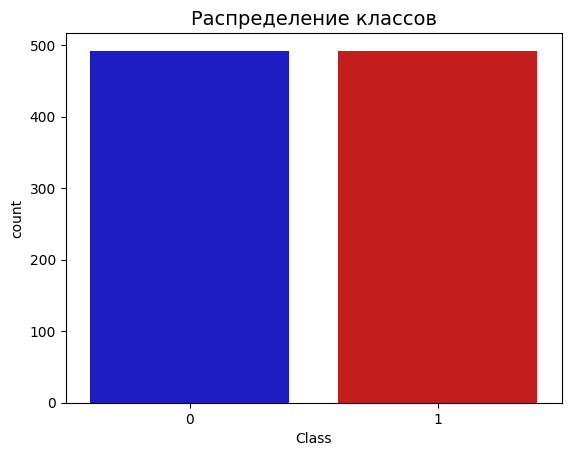

In [29]:
print('Распределение классов в подвыборке')
print(new_df['Class'].value_counts())

# проверяем снова распределение целевой переменной
sns.countplot(x='Class', data=new_df, palette=colors)
plt.title('Распределение классов', fontsize=14)
plt.show()

Матрица корреляций

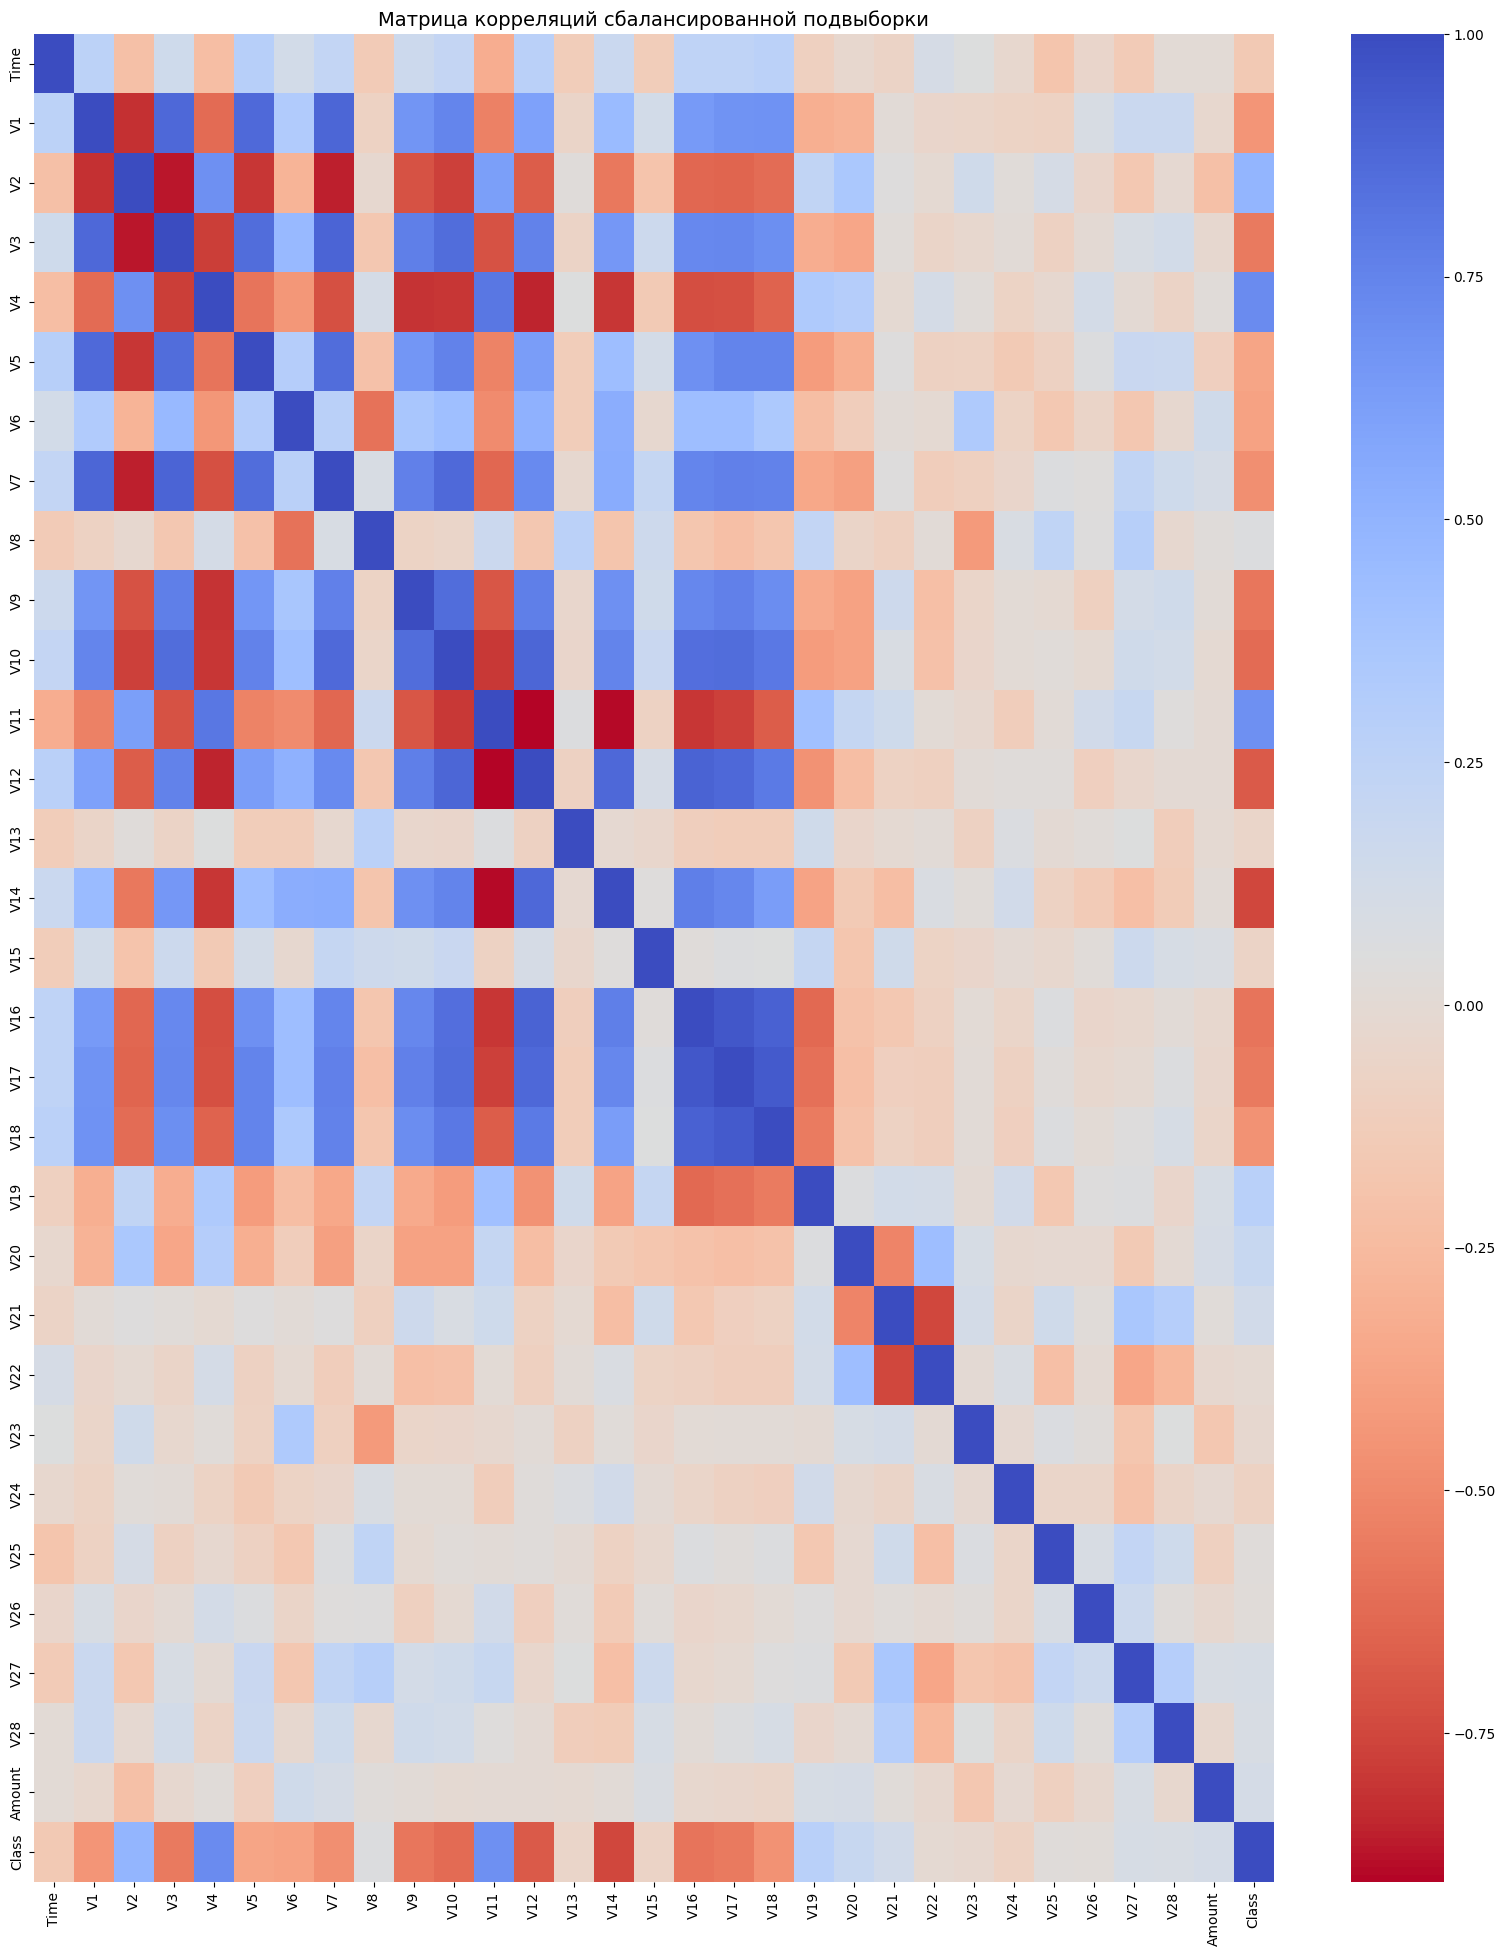

In [30]:
f, ax = plt.subplots(1, 1, figsize=(20, 24))

# Построим матрицу корреляций
corr = new_df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax)
ax.set_title('Матрица корреляций сбалансированной подвыборки', fontsize=14)
plt.show()

Построим теперь Boxplot

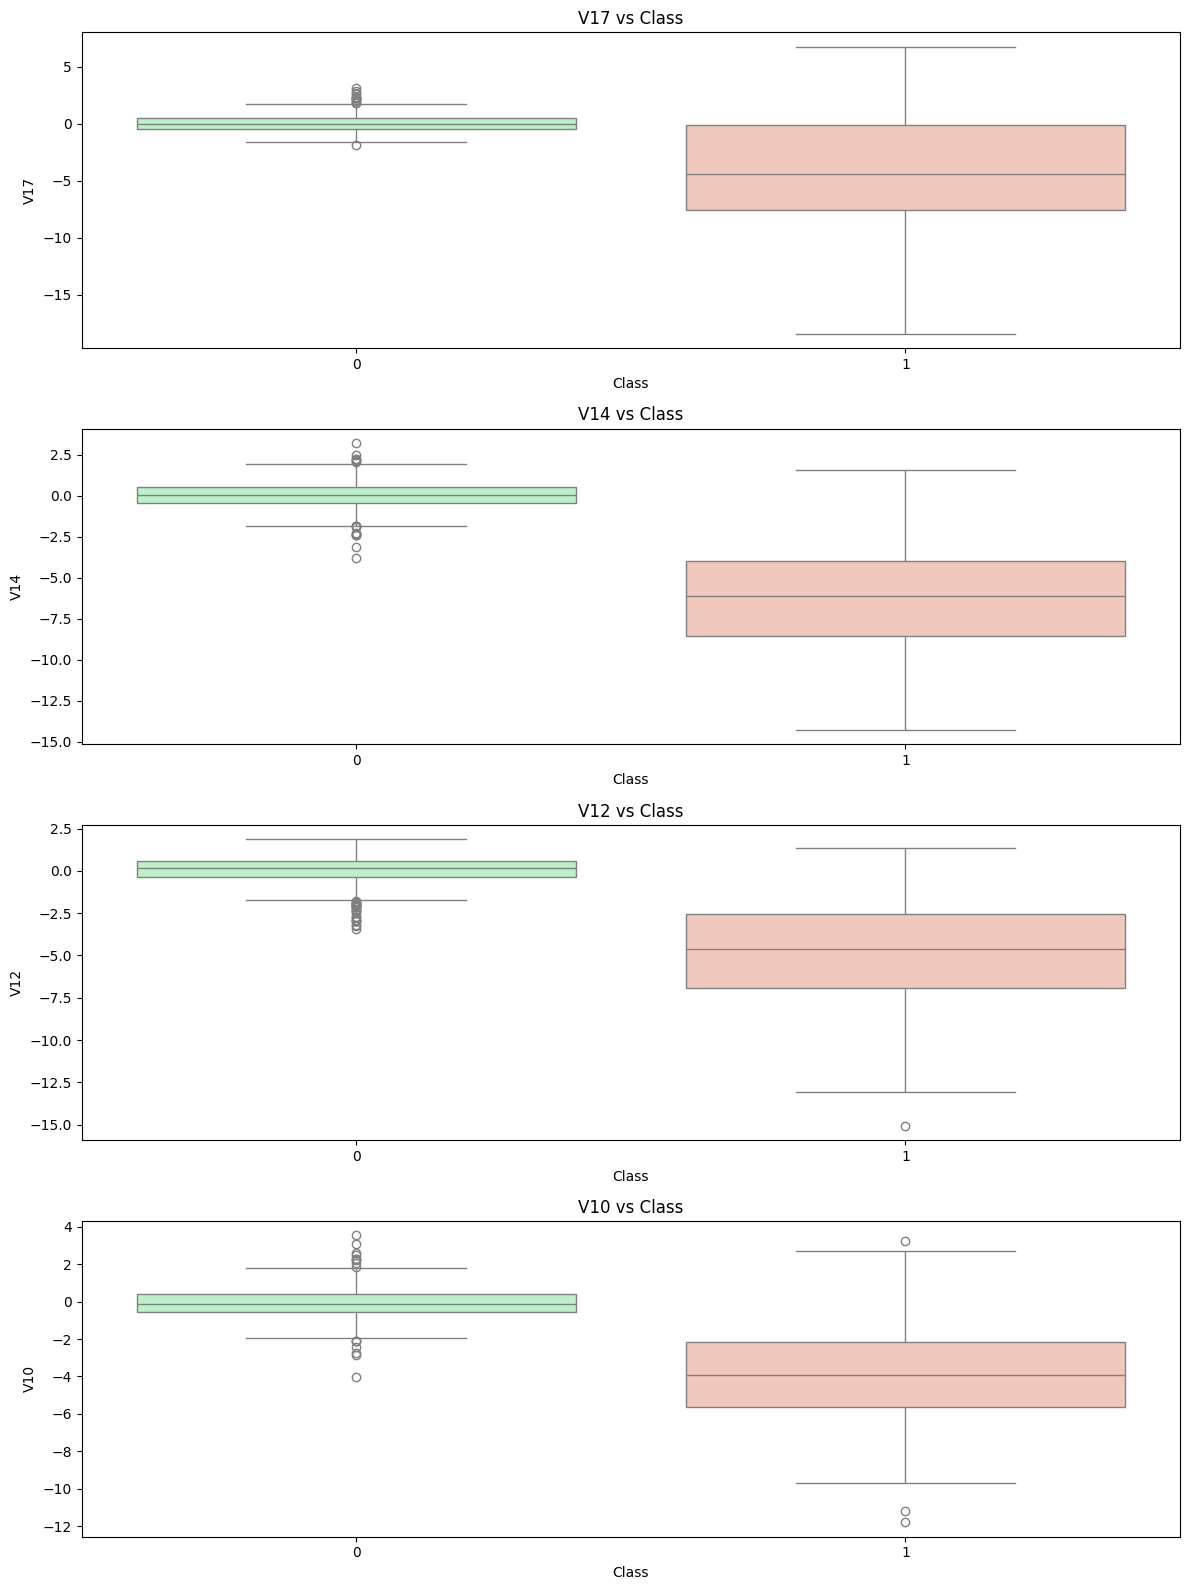

In [46]:
# Boxplot для отрицательных корреляций
f, axes = plt.subplots(4, 1, figsize=(12, 16))

# Отрицательные корреляции
sns.boxplot(x="Class", y="V17", data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('V17 vs Class')

sns.boxplot(x="Class", y="V14", data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('V14 vs Class')

sns.boxplot(x="Class", y="V12", data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('V12 vs Class')

sns.boxplot(x="Class", y="V10", data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('V10 vs Class')

plt.tight_layout()
plt.show()

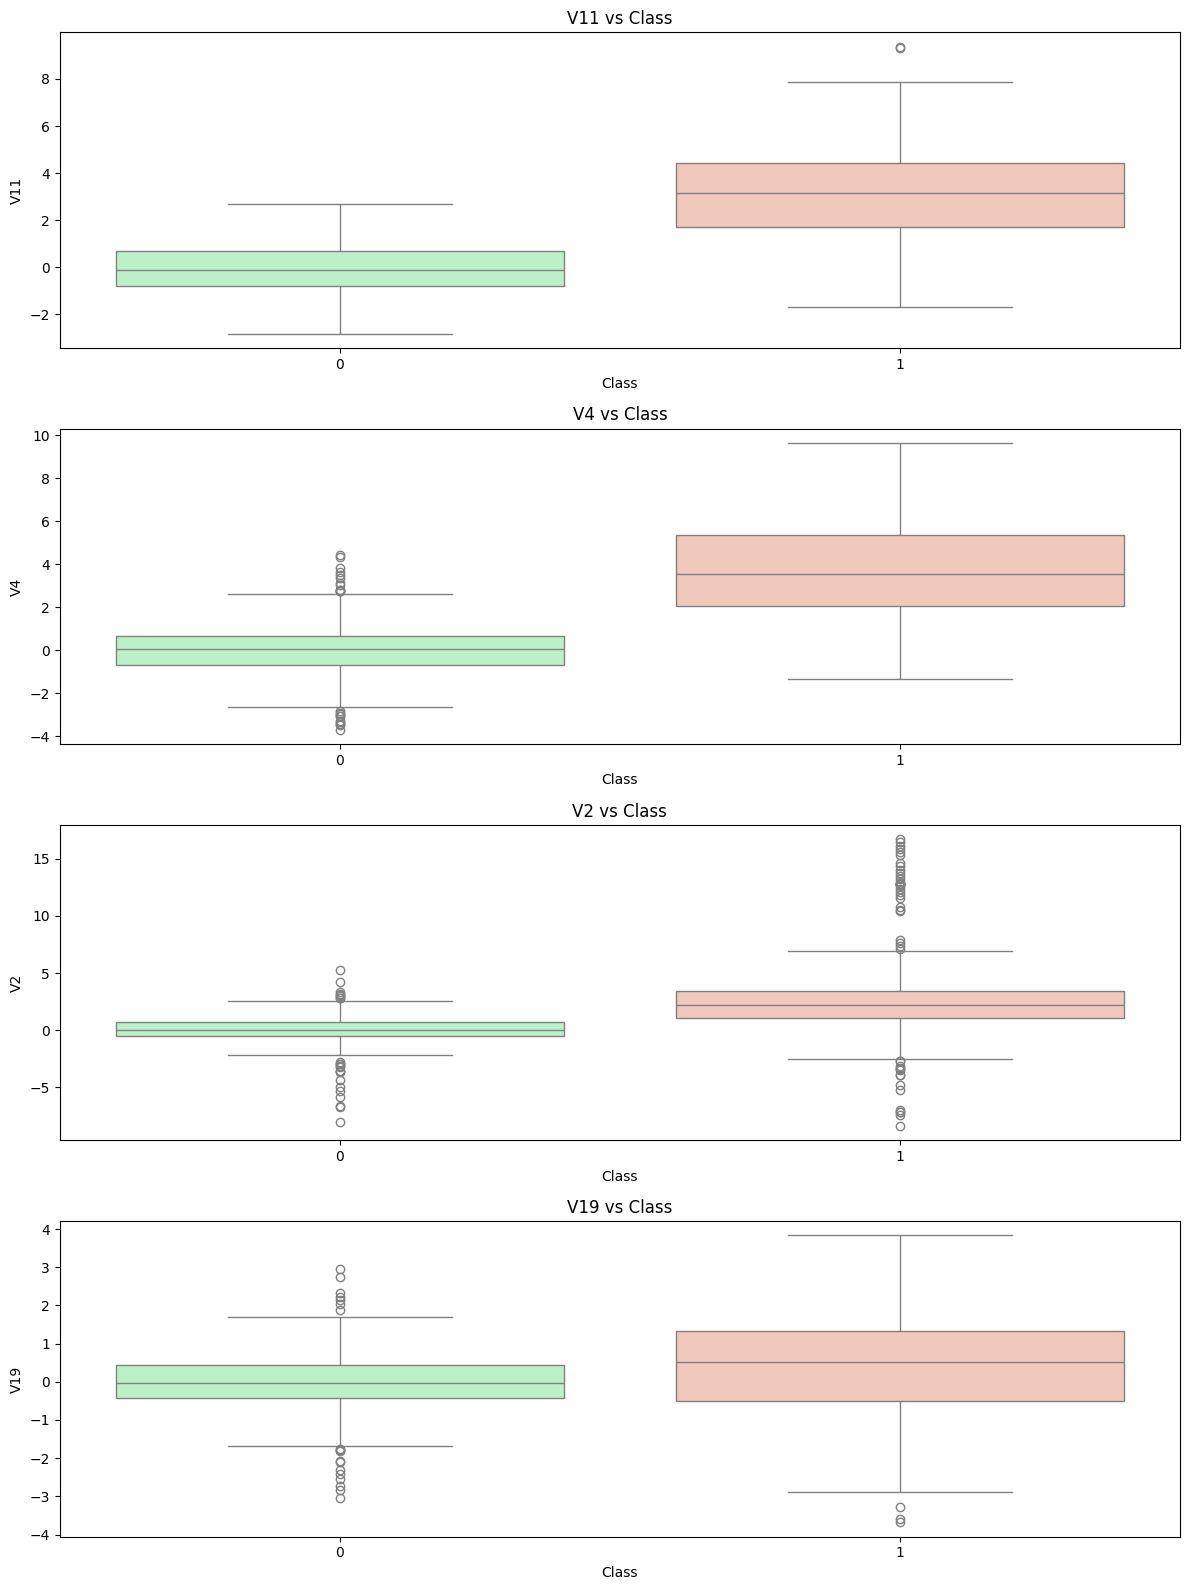

In [47]:
# Boxplot для положительных корреляций
f, axes = plt.subplots(4, 1, figsize=(12, 16))

# Положительные корреляции
sns.boxplot(x="Class", y="V11", data=new_df, palette=colors, ax=axes[0])
axes[0].set_title('V11 vs Class')

sns.boxplot(x="Class", y="V4", data=new_df, palette=colors, ax=axes[1])
axes[1].set_title('V4 vs Class')

sns.boxplot(x="Class", y="V2", data=new_df, palette=colors, ax=axes[2])
axes[2].set_title('V2 vs Class')

sns.boxplot(x="Class", y="V19", data=new_df, palette=colors, ax=axes[3])
axes[3].set_title('V19 vs Class')

plt.tight_layout()
plt.show()

Обработка выбросов

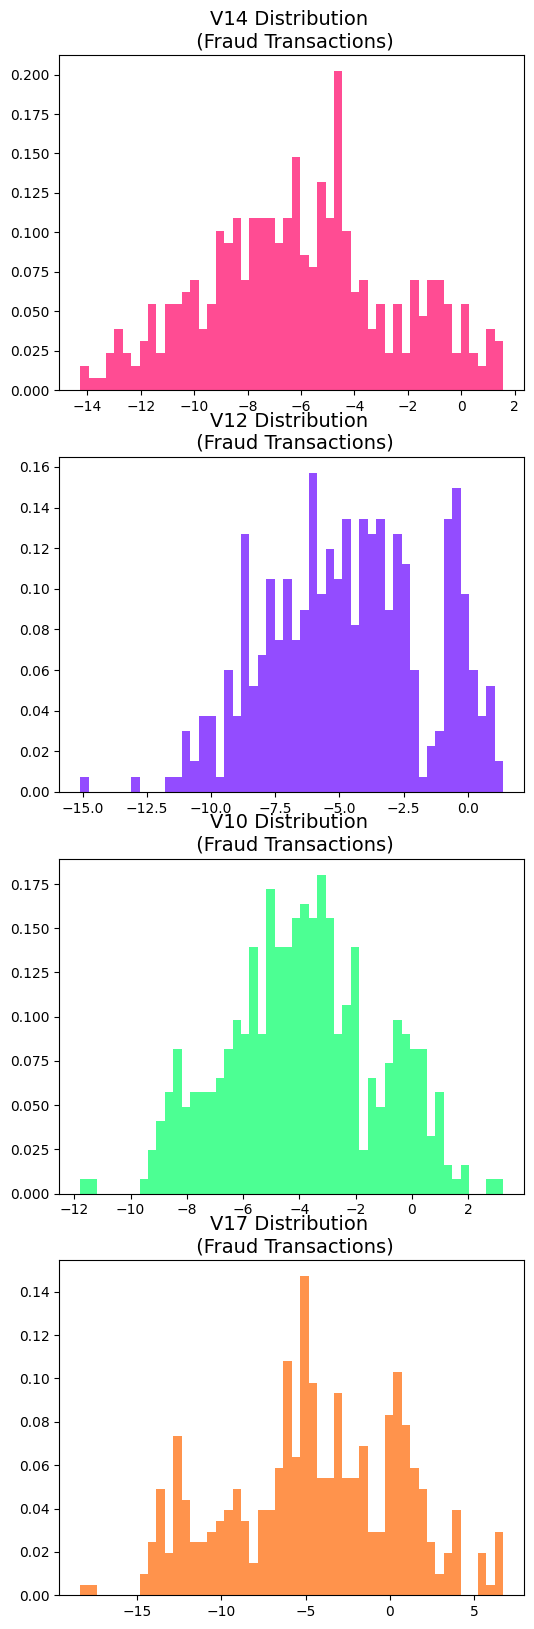

In [49]:
# Строим распределения для признаков с отрицательной корреляцией
from scipy.stats import norm

f, (ax1, ax2, ax3, ax4) = plt.subplots(4,1, figsize=(6, 20))

#### V14
v14_fraud_dist = new_df['V14'].loc[new_df['Class'] == 1].values
ax1.hist(v14_fraud_dist, bins=50, density=True, color='#FF0066', alpha=0.7)
ax1.set_title('V14 Distribution \n (Fraud Transactions)', fontsize=14)

#### V12
v12_fraud_dist = new_df['V12'].loc[new_df['Class'] == 1].values
ax2.hist(v12_fraud_dist, bins=50, density=True, color='#6600FF', alpha=0.7)
ax2.set_title('V12 Distribution \n (Fraud Transactions)', fontsize=14)

#### V10
v10_fraud_dist = new_df['V10'].loc[new_df['Class'] == 1].values
ax3.hist(v10_fraud_dist, bins=50, density=True, color='#00FF66', alpha=0.7)
ax3.set_title('V10 Distribution \n (Fraud Transactions)', fontsize=14)

#### V17
v17_fraud_dist = new_df['V17'].loc[new_df['Class'] == 1].values
ax4.hist(v17_fraud_dist, bins=50, density=True, color='#FF6600', alpha=0.7)
ax4.set_title('V17 Distribution \n (Fraud Transactions)', fontsize=14)

plt.show()

In [35]:
# Удаление выбросов из признака V17
v17_fraud = new_df['V17'].loc[new_df['Class'] == 1].values
q25, q75 = np.percentile(v17_fraud, 25), np.percentile(v17_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
v17_iqr = q75 - q25
print('iqr: {}'.format(v17_iqr))

v17_cut_off = v17_iqr * 1.5
v17_lower, v17_upper = q25 - v17_cut_off, q75 + v17_cut_off
print('Порог: {}'.format(v17_cut_off))
print('V17 нижняя граница: {}'.format(v17_lower))
print('V17 верхняя граница: {}'.format(v17_upper))

outliers = [x for x in v17_fraud if x < v17_lower or x > v17_upper]
print('Количество выбросов: {}'.format(len(outliers)))

new_df_without_outliers  = new_df.drop(new_df[(new_df['V17'] > v17_upper) | (new_df['V17'] < v17_lower)].index)
print('----' * 44)



#### Для остальных признаков на основе V17 описать функцию, в качастве параметра которой будут вытупать выбросы других признаков
### Написать вызов функции по нужным признакам

Квартиль 25: -11.945057187644576 | Квартиль 75: -1.34193993162032
iqr: 10.603117256024255
Порог: 15.904675884036383
V17 нижняя граница: -27.84973307168096
V17 верхняя граница: 14.562735952416062
Количество выбросов: 0
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


In [37]:
# Функция для удаления выбросов
def remove_outliers(feature, df):
    feature_fraud = df[feature].loc[df['Class'] == 1].values
    q25, q75 = np.percentile(feature_fraud, 25), np.percentile(feature_fraud, 75)
    iqr = q75 - q25
    cut_off = iqr * 1.5
    lower, upper = q25 - cut_off, q75 + cut_off

    outliers = [x for x in feature_fraud if x < lower or x > upper]
    print(f'{feature}: количество выбросов - {len(outliers)}')

    return df.drop(df[(df[feature] > upper) | (df[feature] < lower)].index)

# Удаление выбросов для всех признаков
features_to_clean = ['V14', 'V12', 'V10', 'V17']
for feature in features_to_clean:
    new_df_without_outliers = remove_outliers(feature, new_df_without_outliers)
    print('----' * 15)

V14: количество выбросов - 5
------------------------------------------------------------
V12: количество выбросов - 12
------------------------------------------------------------
V10: количество выбросов - 28
------------------------------------------------------------
V17: количество выбросов - 4
------------------------------------------------------------


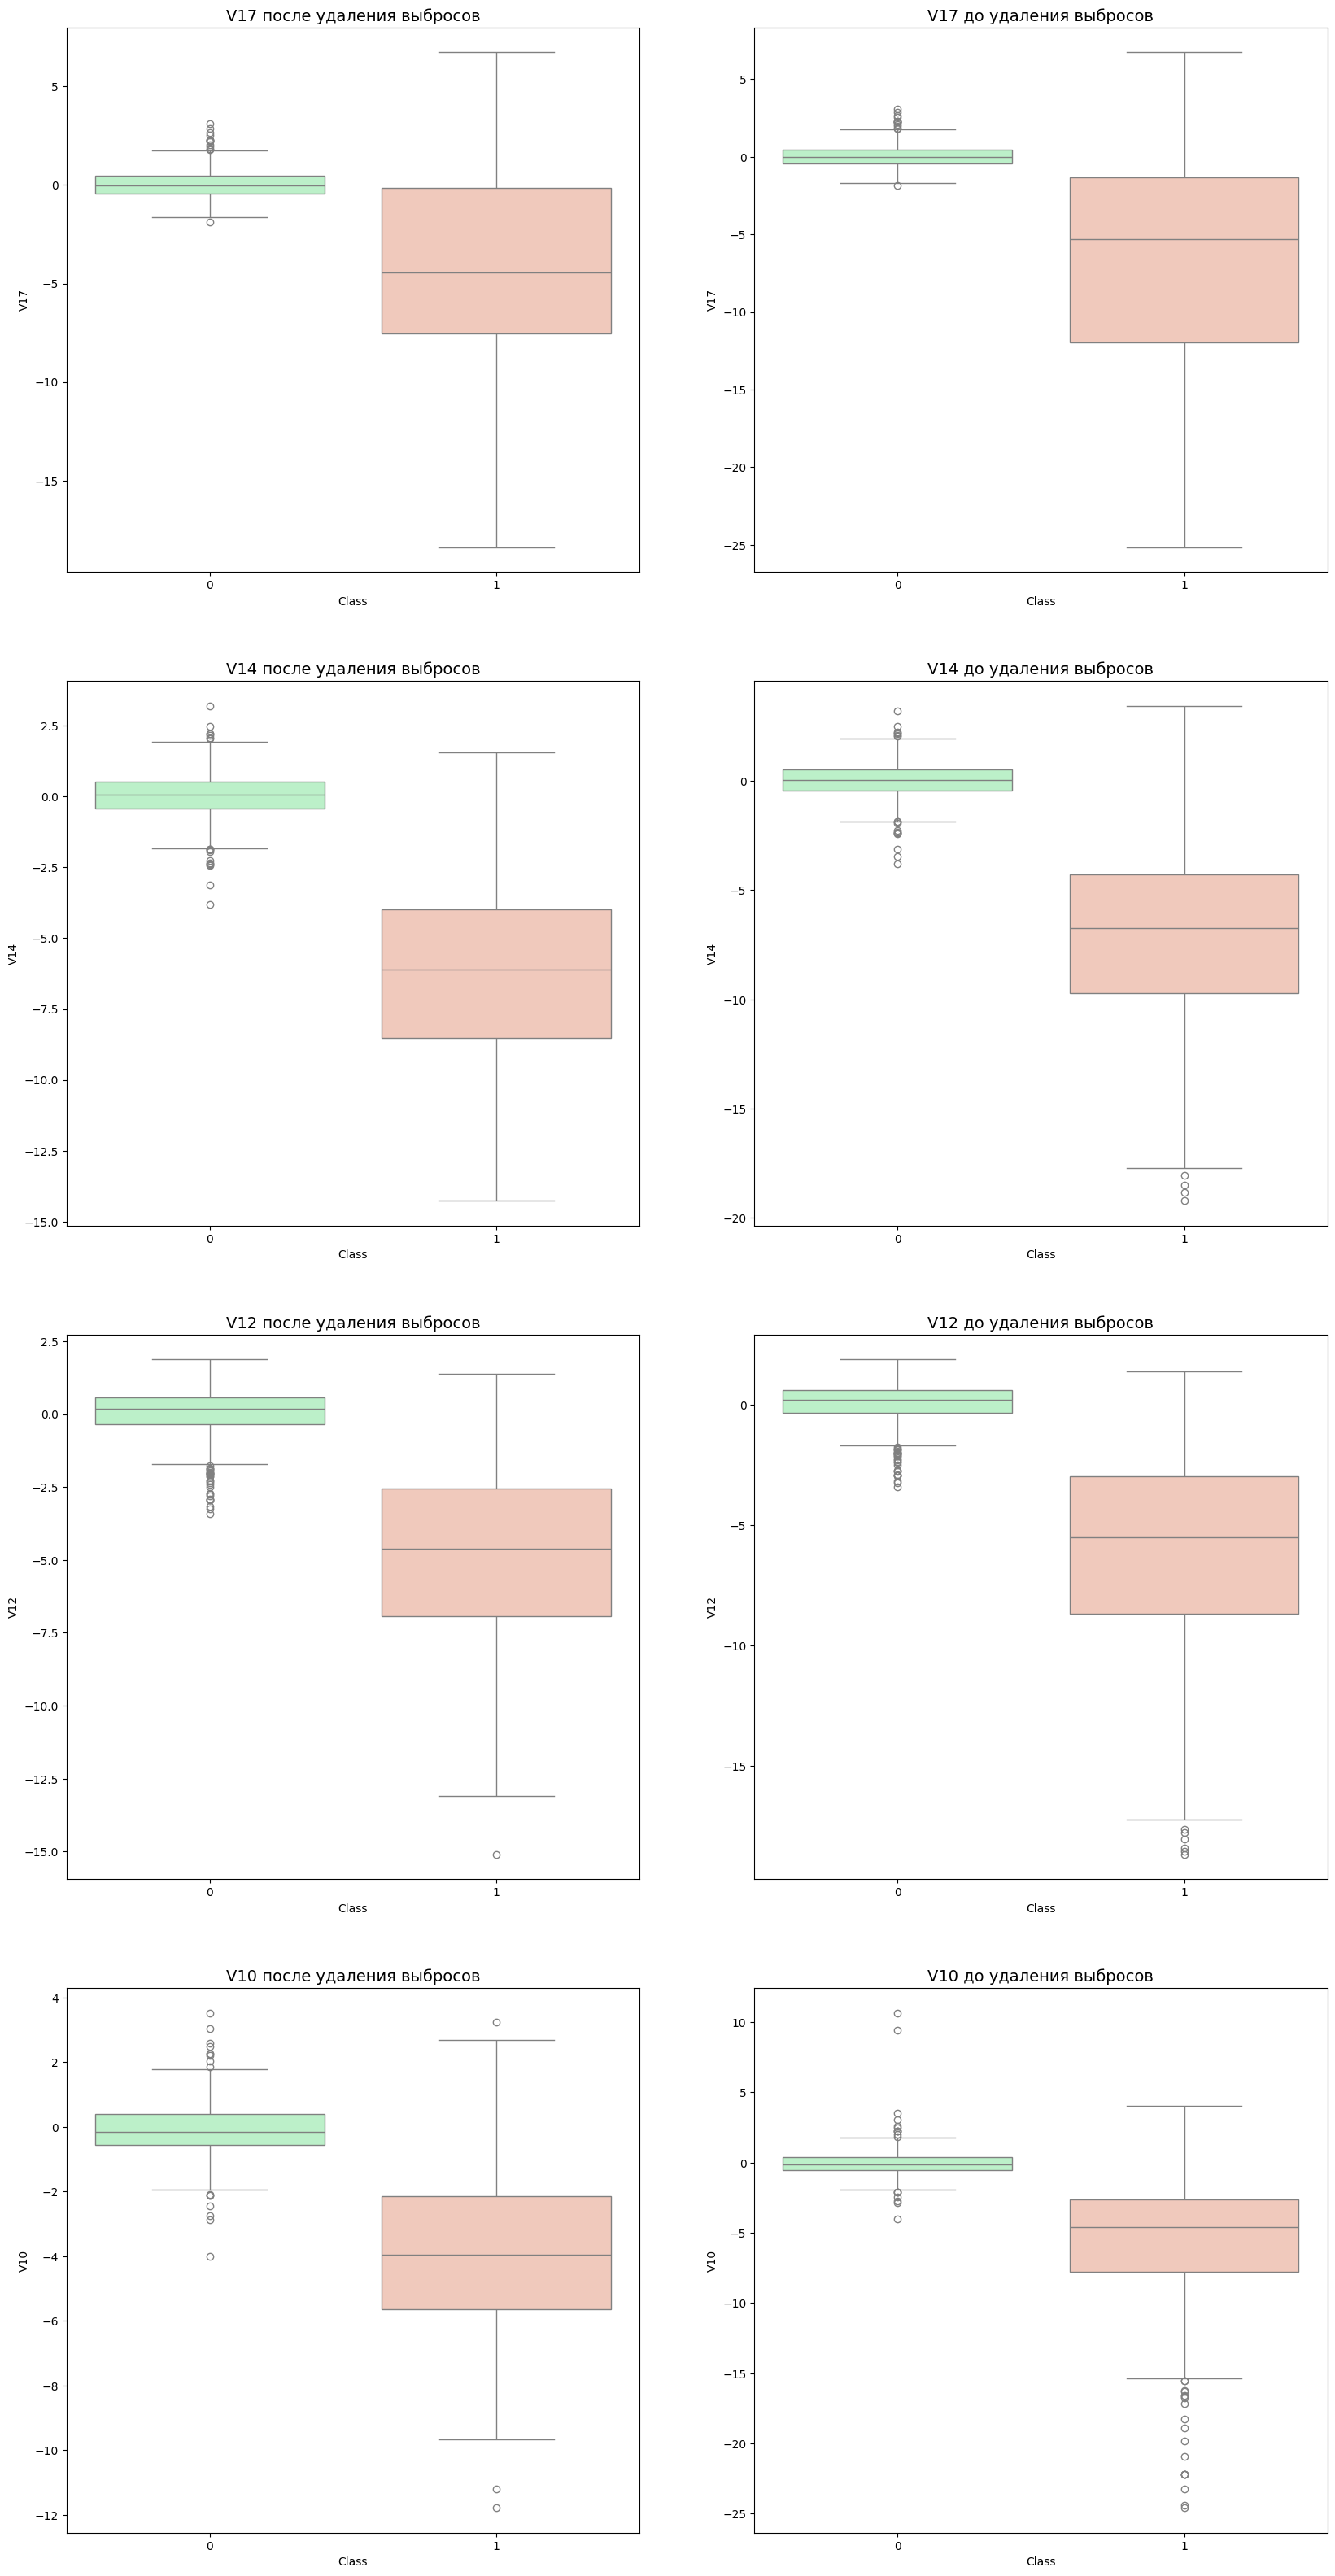

In [38]:
f, ax = plt.subplots(4, 2, figsize=(20,40))
colors = ['#B3F9C5', '#f9c5b3']

# Boxplot для признака V17 после удаления выбросов
sns.boxplot(x="Class", y="V17", data=new_df_without_outliers, ax=ax[0,0], palette=colors)
ax[0,0].set_title("V17 после удаления выбросов", fontsize=14)

# Boxplot для признака V17 до удаления выбросов
sns.boxplot(x="Class", y="V17", data=new_df, ax=ax[0,1], palette=colors)
ax[0,1].set_title("V17 до удаления выбросов", fontsize=14)

# И для остальных признаков тоже
features = ['V14', 'V12', 'V10']
for i, feature in enumerate(features):
    # после удаления выбросов
    sns.boxplot(x="Class", y=feature, data=new_df_without_outliers, ax=ax[i+1,0], palette=colors)
    ax[i+1,0].set_title(f"{feature} после удаления выбросов", fontsize=14)

    # до удаления выбросов
    sns.boxplot(x="Class", y=feature, data=new_df, ax=ax[i+1,1], palette=colors)
    ax[i+1,1].set_title(f"{feature} до удаления выбросов", fontsize=14)

plt.show()

In [39]:
# теперь у нас в датафрейме new_df будут лежать данные без выбросов.

new_df = new_df_without_outliers

Понижение размерности и кластеризация

In [40]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

X = new_df.drop('Class', axis=1)
y = new_df['Class']

X.drop(['Time','Amount'], axis=1, inplace=True) # Tак как Time и Amount не коррелируют почти с таргетом


# T-SNE алгоритм
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("T-SNE заняло {:.2} сек".format(t1 - t0))

# PCA алгоритм
t0 = time.time()
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("PCA заняло {:.2} сек".format(t1 - t0))

# TruncatedSVD алгоритм
t0 = time.time()
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD заняло {:.2} сек".format(t1 - t0))

T-SNE заняло 2.6e+01 сек
PCA заняло 0.067 сек
Truncated SVD заняло 0.065 сек


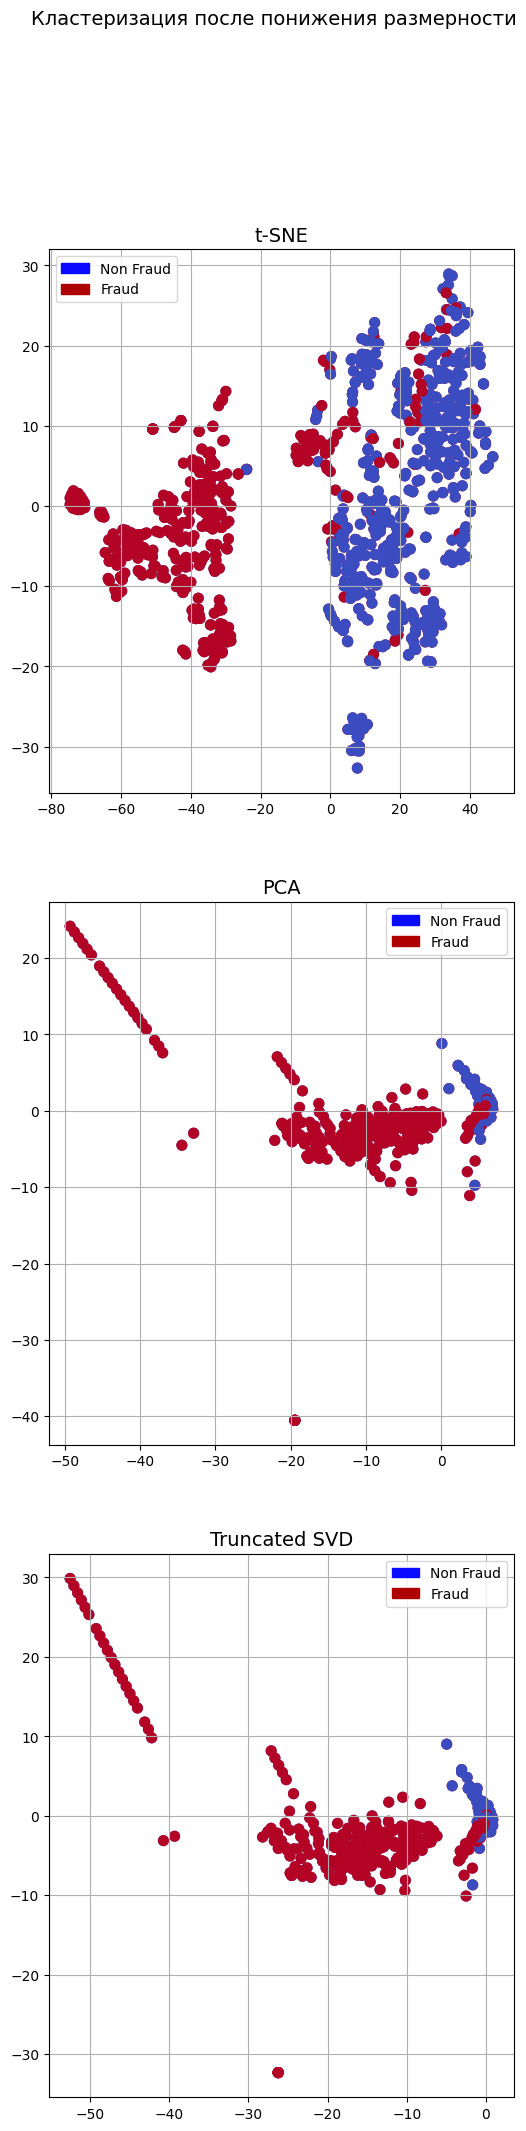

In [50]:
f, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6,24))
f.suptitle('Кластеризация после понижения размерности', fontsize=14)

blue_patch = mpatches.Patch(color='#0A0AFF', label='Non Fraud')
red_patch = mpatches.Patch(color='#AF0000', label='Fraud')

# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='Non Fraud', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)
ax1.grid(True)
ax1.legend(handles=[blue_patch, red_patch])

# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='Non Fraud', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax2.set_title('PCA', fontsize=14)
ax2.grid(True)
ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='Non Fraud', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Fraud', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)
ax3.grid(True)
ax3.legend(handles=[blue_patch, red_patch])

plt.show()